In [6]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,  WikipediaAPIWrapper


In [7]:
import certifi, os
os.environ.setdefault("SSL_CERT_FILE", certifi.where())  # stdlib ssl has no CA bundle on Windows by default

import arxiv
arxiv.Client.query_url_format = "https://export.arxiv.org/api/query?{}"  # arxiv==1.4.8 defaults to http:// and mishandles the 301 redirect to https


In [ ]:
import wikipedia
# The default User-Agent is shared by every user of this package and gets intermittently
# throttled by Wikimedia (empty 200 responses). Use a distinct one per Wikimedia policy:
# https://meta.wikimedia.org/wiki/User-Agent_policy
wikipedia.USER_AGENT = "LangCG-chatbot/1.0"

In [8]:
arxiv_wrapper = ArxivAPIWrapper(top_k_results=3, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper = arxiv_wrapper)

In [9]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [10]:
import certifi, os

print("SSL_CERT_FILE before:", os.environ.get("SSL_CERT_FILE"))
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
print("SSL_CERT_FILE after:", os.environ["SSL_CERT_FILE"])
print("file exists:", os.path.exists(os.environ["SSL_CERT_FILE"]))

import feedparser
feed = feedparser.parse("https://export.arxiv.org/api/query?search_query=all:test&max_results=1")
print("status:", feed.get("status"))
print("bozo:", feed.get("bozo"), feed.get("bozo_exception"))


SSL_CERT_FILE before: C:\Users\jehoo\AppData\Local\anaconda3\envs\all_env\Lib\site-packages\certifi\cacert.pem
SSL_CERT_FILE after: C:\Users\jehoo\AppData\Local\anaconda3\envs\all_env\Lib\site-packages\certifi\cacert.pem
file exists: True
status: 200
bozo: False None


In [13]:
wiki_wrapper = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=wiki_wrapper)
wiki.name

'wikipedia'

In [12]:
wiki.invoke("What is machine learning")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [14]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [15]:
tavily = TavilySearchResults()
tavily.invoke("Attension is all you need")

C:\Users\jehoo\AppData\Local\Temp\ipykernel_15844\3367971032.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


[{'title': 'Attention Is All You Need',
  'url': 'https://arxiv.org/pdf/1706.03762',
  'content': '## Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works. \n\n# Attention Is All You Need \n\nAshish Vaswani ∗\n\nGoogle Brain \n\navaswani@google.com \n\nNoam Shazeer ∗\n\nGoogle Brain \n\nnoam@google.com \n\nNiki Parmar ∗\n\nGoogle Research \n\nnikip@google.com \n\nJakob Uszkoreit ∗\n\nGoogle Research \n\nusz@google.com \n\nLlion Jones ∗\n\nGoogle Research \n\nllion@google.com \n\nAidan N. Gomez ∗ † \n\nUniversity of Toronto \n\naidan@cs.toronto.edu \n\nŁukasz Kaiser ∗\n\nGoogle Brain \n\nlukaszkaiser@google.com \n\nIllia Polosukhin ∗ ‡ \n\nillia.polosukhin@gmail.com \n\n## Abstract [...] is the first transduction model relying entirely on self-attention to compute representations of its input and output without using sequence-aligned RNNs or convolution. In the followi

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [42]:
tools = [arxiv, tavily]

In [43]:
from langchain_openai import AzureChatOpenAI
from langchain_groq import ChatGroq

client = AzureChatOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    api_version= os.getenv("AZURE_OPENAI_API_VERSION"),
    azure_deployment = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME"),
    azure_endpoint= os.getenv("AZURE_OPENAI_ENDPOINT"),
)

In [56]:
llm_with_tools = client.bind_tools(tools, tool_choice="required")

In [57]:
llm_with_tools.invoke("What is the current ai news").tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news and developments'},
  'id': 'call_bKpZWN8Cdqbla7FPR6XDJfNf',
  'type': 'tool_call'}]

In [58]:
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage
from pydantic import BaseModel

In [59]:
class State(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]

In [60]:
def tool_call_llm(state: State):
    return {"messages": llm_with_tools.invoke(state.messages)}

In [61]:
from langgraph.prebuilt import ToolNode, tools_condition

graph = StateGraph(State)

graph.add_node("llm_with_tools", tool_call_llm)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "llm_with_tools")
graph.add_conditional_edges(
    "llm_with_tools",
    tools_condition
)
graph.add_edge("tools", END)

graph_builder = graph.compile()

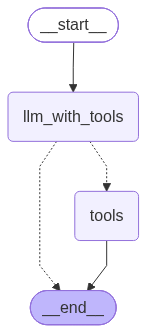

In [62]:
from IPython.display import display, Image

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [67]:
from langchain_core.messages import HumanMessage, AIMessage
messages = graph_builder.invoke({"messages": [HumanMessage(content="Heard lionel messi has retired from football")]})

In [68]:
from pprint import pprint
for result in messages['messages']:
    result.pretty_print()

================================ Human Message =================================

Heard lionel messi has retired from football
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_dXrkbZYlQtpR843upX7zYtUc)
 Call ID: call_dXrkbZYlQtpR843upX7zYtUc
  Args:
    query: Has Lionel Messi retired from professional football 2026
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Mint - Lionel Messi retired from international football in...", "url": "https://www.facebook.com/mint.live/posts/lionel-messi-retired-from-international-football-in-august-2026-after-a-remarkab/1531866618983053", "content": "## Mint's Post\n\n### Mint\n\n4h  ·\n\nLionel Messi retired from international football in August 2026 after a remarkable career with Argentina, continuing at Inter Miami.\n\nLionel Messi Net Worth 2026: Salary, endorsements, cars, properties and luxu